# Phase 5: Evaluation & Interpretability

All models loaded from `outputs/models/`. Metrics loaded from `outputs/results/all_model_results.csv` (written by notebooks 02 and 03 — not recomputed here).

1. Load all models and test data
2. Load results from previous notebooks
3. Per-class F1 bar chart
4. Confusion matrices (XGBoost vs FT-Transformer)
5. SHAP feature importance
6. Final verdict

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
)
from torch.utils.data import DataLoader, TensorDataset

from config import (
    OUTPUTS_DIR, MODELS_DIR, PLOTS_DIR, RESULTS_CSV_PATH,
    XGBOOST_PATH, LIGHTGBM_PATH, CATBOOST_PATH, PIPELINE_PATH,
)
from preprocessing.pipeline import PreprocessingPipeline
from evaluation.metrics import (
    plot_confusion_matrix,
    plot_side_by_side_confusion_matrices,
    plot_shap_summary,
)
from models.deep_learning import _MLP, _FTTransformer, _device

print('All imports OK.')

All imports OK.


## 1. Load Test Data & All Models

In [2]:
# ── Test data ──────────────────────────────────────────────────────────────
X_test = np.load(os.path.join(OUTPUTS_DIR, 'X_test.npy'))
y_test = np.load(os.path.join(OUTPUTS_DIR, 'y_test.npy'))
print(f'Test set:  {X_test.shape}  |  classes: {np.unique(y_test)}')

# Feature names from fitted pipeline
pipeline      = PreprocessingPipeline.load(PIPELINE_PATH)
feature_names = pipeline.feature_cols
n_features    = len(feature_names)
print(f'Features ({n_features}): {feature_names}')

Test set:  (1120369, 20)  |  classes: [1 2 3 4]
Features (20): ['Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Weather_Condition', 'Amenity', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Civil_Twilight', 'Duration_Seconds', 'Cluster']


In [3]:
# ── Boosting models ────────────────────────────────────────────────────────
from catboost import CatBoostClassifier

xgb_model = joblib.load(XGBOOST_PATH)
lgb_model = joblib.load(LIGHTGBM_PATH)
cat_model = CatBoostClassifier()
cat_model.load_model(CATBOOST_PATH)

print('Boosting models loaded.')

# ── Deep learning models ───────────────────────────────────────────────────
device = _device()

mlp_model = _MLP(n_features).to(device)
mlp_model.load_state_dict(
    torch.load(os.path.join(MODELS_DIR, 'mlp_best.pt'), map_location=device)
)
mlp_model.eval()

ft_model = _FTTransformer(n_features).to(device)
ft_model.load_state_dict(
    torch.load(os.path.join(MODELS_DIR, 'ft_transformer_best.pt'), map_location=device)
)
ft_model.eval()

print(f'DL models loaded on {device}.')

Boosting models loaded.
DL models loaded on cuda.


In [4]:
LGB_THRESHOLDS = [0.50, 0.50, 0.82, 0.50]   # best thresholds from notebook 02

lgb_proba = lgb_model.predict_proba(X_test)
scaled     = lgb_proba / LGB_THRESHOLDS
lgb_preds  = scaled.argmax(axis=1) + 1        # 0-indexed → 1-indexed

def dl_predict(model, X, batch_size=2048):
    """Batched inference for PyTorch models. Returns 1-indexed predictions."""
    loader = DataLoader(
        TensorDataset(torch.tensor(X, dtype=torch.float32)),
        batch_size=batch_size, shuffle=False, num_workers=0,
    )
    logits = []
    with torch.no_grad():
        for (xb,) in loader:
            logits.append(model(xb.to(device)).cpu())
    return torch.cat(logits).argmax(dim=1).numpy() + 1

ft_preds = dl_predict(ft_model, X_test)

print('Predictions ready for LightGBM+Thresholds (best model) and FT-Transformer.')

Predictions ready for LightGBM+Thresholds (best model) and FT-Transformer.


## 2. Load Results from Previous Notebooks

In [5]:
results_df = pd.read_csv(RESULTS_CSV_PATH, index_col='Model')

results_df.style \
    .format('{:.4f}') \
    .background_gradient(subset=['Macro F1'], cmap='RdYlGn') \
    .background_gradient(subset=['F1-C1', 'F1-C4'], cmap='RdYlGn')

,Accuracy,Macro F1,Weighted F1,F1-C1,F1-C2,F1-C3,F1-C4
Model,,,,,,,
XGBoost_Optuna,0.7230,0.5021,0.7533,0.3146,0.8104,0.5741,0.3094
XGBoost_Optuna+Thresholds,0.7503,0.5062,0.7771,0.2976,0.8379,0.5874,0.3019
LightGBM_Optuna,0.7214,0.5018,0.7515,0.3254,0.8097,0.5673,0.3046
LightGBM_Optuna+Thresholds,0.7496,0.5070,0.7759,0.3115,0.8378,0.5813,0.2974
CatBoost_Optuna,0.7169,0.4908,0.7479,0.3018,0.8063,0.5660,0.2889
CatBoost_Optuna+Thresholds,0.7466,0.4954,0.7738,0.2822,0.8365,0.5787,0.2840
MLP,0.4173,0.3043,0.5070,0.1019,0.5315,0.4732,0.1108
FT-Transformer,0.5293,0.3559,0.6089,0.1073,0.6525,0.4970,0.1669


## 4. Per-Class F1 Bar Chart

Saved: e:\Projects\Accident Severity Prediction\outputs\plots\phase5_per_class_f1.png


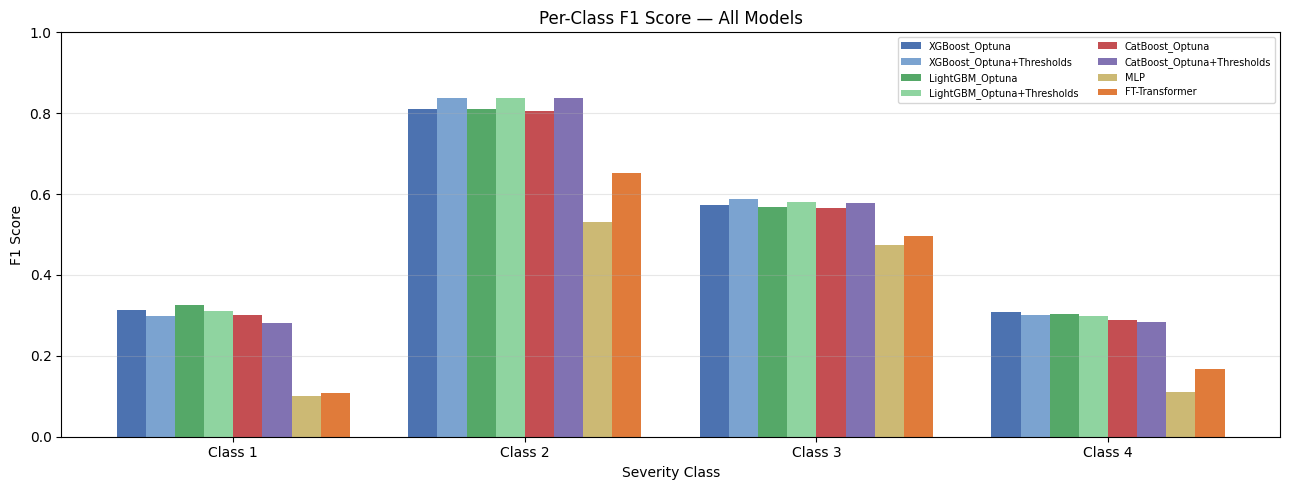

In [6]:
classes = [1, 2, 3, 4]
x       = np.arange(len(classes))
width   = 0.10
colors  = ['#4C72B0', '#7BA3D0', '#55A868', '#8FD4A0',
           '#C44E52', '#8172B2', '#CCB974', '#E07B3A']

fig, ax = plt.subplots(figsize=(13, 5))
for i, model_name in enumerate(results_df.index):
    per_class = [results_df.loc[model_name, f'F1-C{c}'] for c in classes]
    ax.bar(x + i * width, per_class, width, label=model_name, color=colors[i])

ax.set_xlabel('Severity Class')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score — All Models')
ax.set_xticks(x + width * 3.5)
ax.set_xticklabels([f'Class {c}' for c in classes])
ax.set_ylim(0, 1.0)
ax.legend(fontsize=7, ncol=2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
path = os.path.join(PLOTS_DIR, 'phase5_per_class_f1.png')
plt.savefig(path, dpi=120, bbox_inches='tight')
print(f'Saved: {path}')
plt.show()

## 5. Confusion Matrices

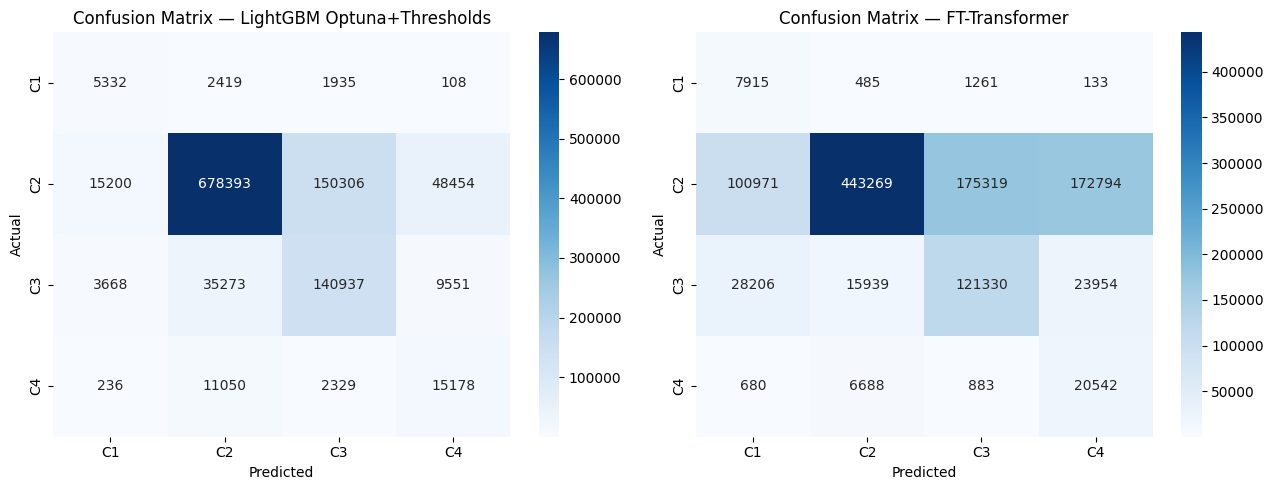

In [7]:
# Side-by-side: best model (LightGBM + thresholds) vs best DL model (FT-Transformer)
plot_side_by_side_confusion_matrices(
    y_test,
    lgb_preds, 'LightGBM Optuna+Thresholds',
    ft_preds,  'FT-Transformer',
)

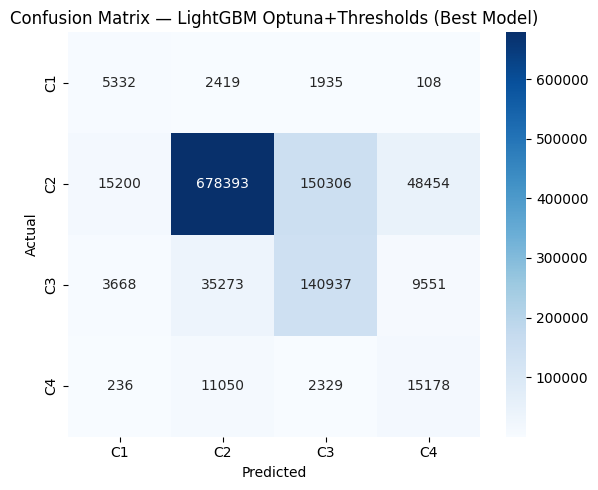

In [8]:
# Individual confusion matrix for the best overall model
plot_confusion_matrix(y_test, lgb_preds, 'LightGBM Optuna+Thresholds (Best Model)')

## 6. SHAP Feature Importance

Using `TreeExplainer` on LightGBM (best model). SHAP shows which features push predictions toward each severity class.

In [9]:
# Per-class beeswarm plots for Class 1 and Class 4 (the critical minorities)
plot_shap_summary(lgb_model, X_test, feature_names, 'LightGBM_Optuna')

  SHAP plot saved: e:\Projects\Accident Severity Prediction\outputs\plots\shap_LightGBM_Optuna_Class1.png
  SHAP plot saved: e:\Projects\Accident Severity Prediction\outputs\plots\shap_LightGBM_Optuna_Class4.png


shap_values shape: (5000, 20, 4)
mean_abs_shap shape: (20,)
Saved: e:\Projects\Accident Severity Prediction\outputs\plots\phase5_shap_global.png


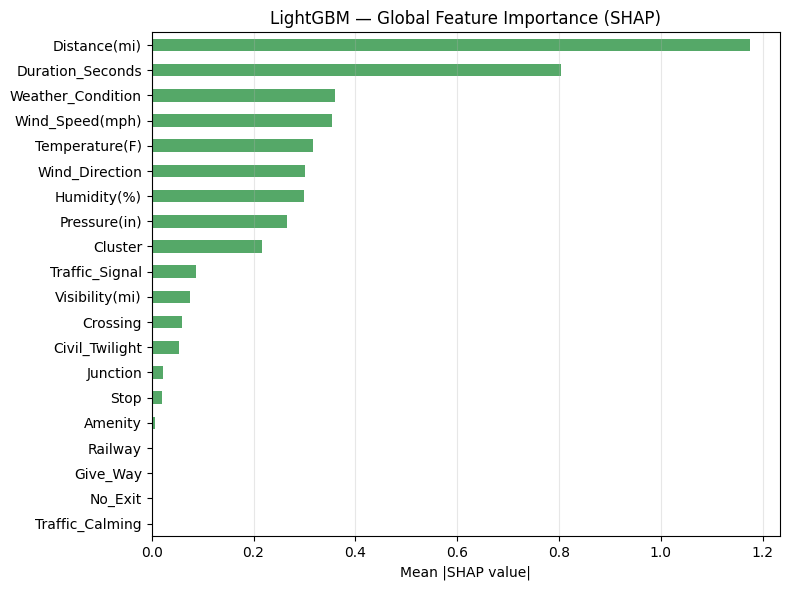

In [10]:
import shap

explainer   = shap.TreeExplainer(lgb_model)
sample      = X_test[:5000]
shap_values = explainer.shap_values(sample)

# shap_values shape: (n_samples, n_features, n_classes) for LightGBM multi-class
# Mean |SHAP| per feature across all samples and all classes
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    mean_abs_shap = np.abs(shap_values).mean(axis=0).mean(axis=1)
elif isinstance(shap_values, list):
    mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

print(f'shap_values shape: {np.array(shap_values).shape}')
print(f'mean_abs_shap shape: {mean_abs_shap.shape}')

shap_df = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
shap_df.plot.barh(ax=ax, color='#55A868')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('LightGBM — Global Feature Importance (SHAP)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
path = os.path.join(PLOTS_DIR, 'phase5_shap_global.png')
plt.savefig(path, dpi=120, bbox_inches='tight')
print(f'Saved: {path}')
plt.show()

## 7. Final Verdict & Save Results

In [13]:
best_name = results_df['Macro F1'].idxmax()
best_row  = results_df.loc[best_name]

print('=' * 65)
print('FINAL VERDICT')
print('=' * 65)
print(f'Best model:      {best_name}')
print(f'Macro F1:        {best_row["Macro F1"]:.4f}')
print(f'F1 Class 1:      {best_row["F1-C1"]:.4f}')
print(f'F1 Class 4:      {best_row["F1-C4"]:.4f}')
print('=' * 65)

FINAL VERDICT
Best model:      LightGBM_Optuna+Thresholds
Macro F1:        0.5070
F1 Class 1:      0.3115
F1 Class 4:      0.2974


In [12]:
print(f'Results at: {RESULTS_CSV_PATH}')
print()
print(results_df[['Accuracy', 'Macro F1', 'F1-C1', 'F1-C4']].to_string())

Results at: e:\Projects\Accident Severity Prediction\outputs\results\all_model_results.csv

                            Accuracy  Macro F1   F1-C1   F1-C4
Model                                                         
XGBoost_Optuna                0.7230    0.5021  0.3146  0.3094
XGBoost_Optuna+Thresholds     0.7503    0.5062  0.2976  0.3019
LightGBM_Optuna               0.7214    0.5018  0.3254  0.3046
LightGBM_Optuna+Thresholds    0.7496    0.5070  0.3115  0.2974
CatBoost_Optuna               0.7169    0.4908  0.3018  0.2889
CatBoost_Optuna+Thresholds    0.7466    0.4954  0.2822  0.2840
MLP                           0.4173    0.3043  0.1019  0.1108
FT-Transformer                0.5293    0.3559  0.1073  0.1669
